# Sprint 1 - Configuração e versionamento

In [22]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from scipy import stats
import cv2
import os

In [23]:
# Caminho base do projeto (pasta onde está este notebook)
base_dir = os.getcwd()
# Databricks
# base_dir = '/Workspace/Users/leonardobadell@protonmail.com/MIni-projeto-avaliativo-modulo-2'

# Caminhos das pastas com imagens
path_def_front = os.path.join(base_dir, 'def_front')
path_ok_front = os.path.join(base_dir, 'ok_front')

# Listar todos os arquivos de imagem de cada pasta
imagens_def = [os.path.join(path_def_front, f) for f in os.listdir(path_def_front) 
               if f.endswith(('.jpg', '.jpeg', '.png'))]
imagens_ok = [os.path.join(path_ok_front, f) for f in os.listdir(path_ok_front) 
              if f.endswith(('.jpg', '.jpeg', '.png'))]

# Criar DataFrame com Pandas
df_imagens = pd.DataFrame({
    'caminho': imagens_def + imagens_ok,
    'classe': ['def_front'] * len(imagens_def) + ['ok_front'] * len(imagens_ok)
})

# Criar label numérica usando np.where: 1 = defeito, 0 = ok
df_imagens['label'] = np.where(df_imagens['classe'] == 'def_front', 1, 0)

# Exibir informações do dataset
print(f"Total de imagens carregadas: {len(df_imagens)}")
print(f"\nDistribuição de classes:")
print(df_imagens['classe'].value_counts())
print(f"\nPrimeiras 5 linhas do dataset:")
display(df_imagens.head())

Total de imagens carregadas: 1300

Distribuição de classes:
classe
def_front    781
ok_front     519
Name: count, dtype: int64

Primeiras 5 linhas do dataset:


,caminho,classe,label
0,c:\Users\leonardo.badell\MIni-projeto-avaliati...,def_front,1
1,c:\Users\leonardo.badell\MIni-projeto-avaliati...,def_front,1
2,c:\Users\leonardo.badell\MIni-projeto-avaliati...,def_front,1
3,c:\Users\leonardo.badell\MIni-projeto-avaliati...,def_front,1
4,c:\Users\leonardo.badell\MIni-projeto-avaliati...,def_front,1


# Sprint 2 - Análise exploratória clássica (OpenCV)

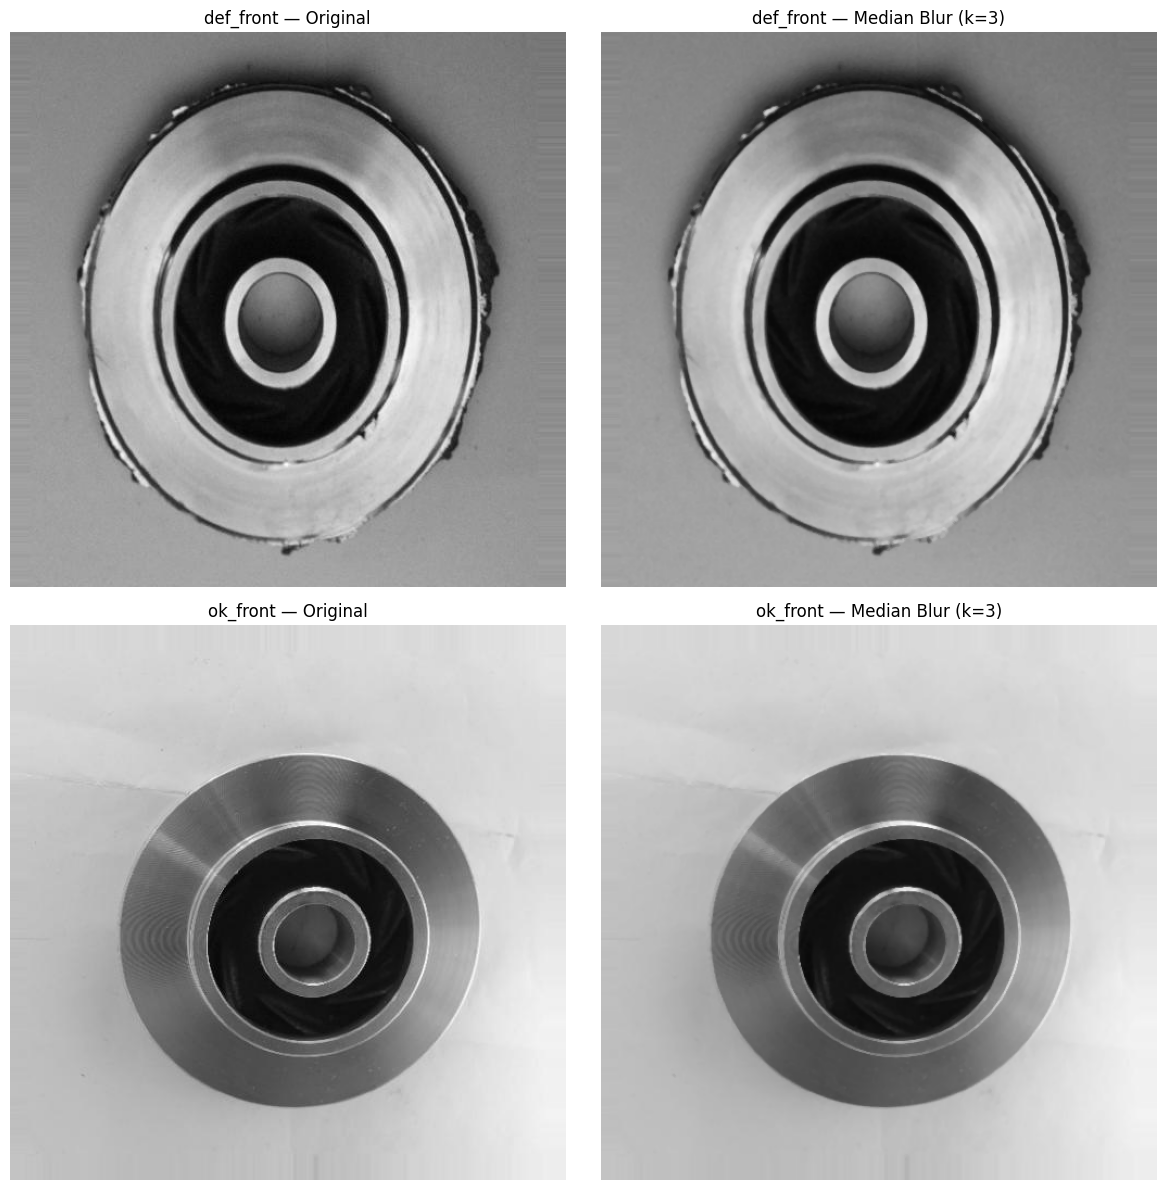

In [24]:
img_def_front = cv2.imread(imagens_def[0])
img_ok_front = cv2.imread(imagens_ok[0])

def aplicar_median_blur(img, k=3):
    img_u8 = img.astype(np.uint8)
    return cv2.medianBlur(img_u8, k)

img_def_blur = aplicar_median_blur(img_def_front)
img_ok_blur = aplicar_median_blur(img_ok_front)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(img_def_front, cmap='gray')
axes[0, 0].set_title('def_front — Original')
axes[0, 1].imshow(img_def_blur, cmap='gray')
axes[0, 1].set_title('def_front — Median Blur (k=3)')

axes[1, 0].imshow(img_ok_front, cmap='gray')
axes[1, 0].set_title('ok_front — Original')
axes[1, 1].imshow(img_ok_blur, cmap='gray')
axes[1, 1].set_title('ok_front — Median Blur (k=3)')

for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

def_front — média: 131.58 | desvio padrão: 55.93
ok_front  — média: 167.15 | desvio padrão: 62.90
Teste KS (def_front vs ok_front): estatística=0.4598, p-valor=0.0000


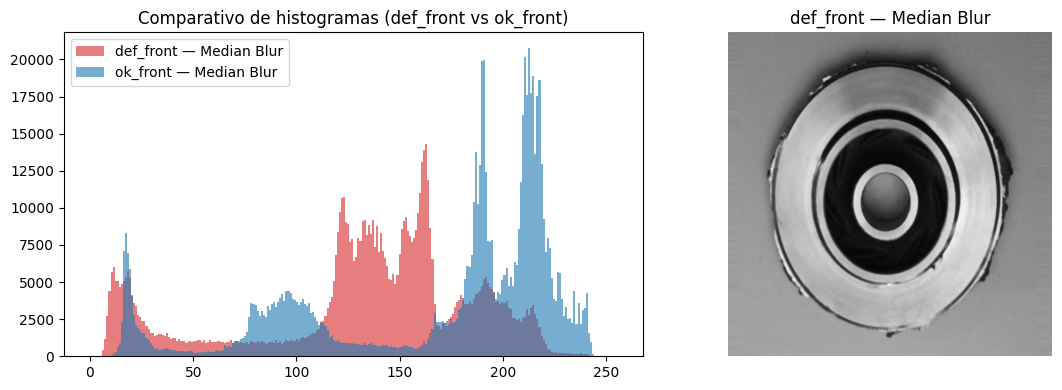

In [25]:
# --- Comparativo estatístico e histogramas: def_front vs ok_front (Median Blur) ---
media_def, desvio_def = img_def_blur.mean(), img_def_blur.std()
media_ok, desvio_ok = img_ok_blur.mean(), img_ok_blur.std()
estatistica_ks, p_valor = stats.ks_2samp(img_def_blur.ravel(), img_ok_blur.ravel())

print(f"def_front — média: {media_def:.2f} | desvio padrão: {desvio_def:.2f}")
print(f"ok_front  — média: {media_ok:.2f} | desvio padrão: {desvio_ok:.2f}")
print(f"Teste KS (def_front vs ok_front): estatística={estatistica_ks:.4f}, p-valor={p_valor:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(img_def_blur.ravel(), bins=256, range=(0, 255), color='tab:red', alpha=0.6, label='def_front — Median Blur')
axes[0].hist(img_ok_blur.ravel(), bins=256, range=(0, 255), color='tab:blue', alpha=0.6, label='ok_front — Median Blur')
axes[0].set_title('Comparativo de histogramas (def_front vs ok_front)')
axes[0].legend()

axes[1].imshow(img_def_blur, cmap='gray')
axes[1].set_title('def_front — Median Blur')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Sprint 3 - Destaque de características

# Sprint 4 - Ingestão de dados e augmentation (Keras)

# Sprint 5 - A arquitetura CNN e treinamento

# Sprint 6 - Auditoria e gravação